In [23]:
!pip install pulp -q

import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

In [24]:
try:
    from google.colab import files
    uploaded = files.upload()
    print("File terupload:", list(uploaded.keys()))
except ImportError:
    print("Bukan di Colab -> pastikan ke-10 file CSV sudah ada di direktori kerja saat ini.")

UP = "."

Saving trend_nasional_2020_2025.csv to trend_nasional_2020_2025 (3).csv
Saving trend_jatim_2024_2025.csv to trend_jatim_2024_2025 (3).csv
Saving Number of General Hospital, Specialized Hospital, Public Health Center, Primary Clinic, and Integrated Health Post by Province, 2020.csv to Number of General Hospital, Specialized Hospital, Public Health Center, Primary Clinic, and Integrated Health Post by Province, 2020 (1).csv
Saving Number of General Hospital, Specialized Hospital, Public Health Center with Inpatient Care, and Public Health Center without Inpatient Care by Province, 2025.csv to Number of General Hospital, Specialized Hospital, Public Health Center with Inpatient Care, and Public Health Center without Inpatient Care by Province, 2025 (1).csv
Saving jatim_25.csv to jatim_25 (1).csv
Saving jatim_24.csv to jatim_24 (1).csv
Saving jatim_23.csv to jatim_23 (1).csv
Saving jatim_22.csv to jatim_22 (1).csv
Saving indeks_risiko_jatim_2025.csv to indeks_risiko_jatim_2025 (3).csv
Savi

In [25]:
def clean_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = (df[c].astype(str)
                     .str.replace("–", "0", regex=False)
                     .str.replace("-", "0", regex=False)
                     .str.replace("...", "", regex=False)
                     .str.replace(",", "", regex=False)
                     .str.strip())
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

df_nat_2020 = pd.read_csv(f"{UP}/clean_nasional_2020.csv")
df_nat_2020.columns = [c.strip() for c in df_nat_2020.columns]
df_nat_2020 = df_nat_2020.rename(columns={
    "Provinsi": "wilayah",
    "Number of General Hospital": "rs_umum",
    "Number of Specialized Hospital": "rs_khusus",
    "Number of Public Health Center with Inpatient Care": "puskesmas_rawat_inap",
    "Number of Public Health Center without Inpatient Care": "puskesmas_non_rawat_inap",
    "Number of Primary Clinic": "klinik_pratama",
    "Number of Integrated Health Post": "posyandu",
})
df_nat_2020 = df_nat_2020[~df_nat_2020["wilayah"].isin(["Indonesia", "Keterangan"])]
df_nat_2020 = df_nat_2020[df_nat_2020["wilayah"].notna()]
df_nat_2020 = df_nat_2020[~df_nat_2020["wilayah"].astype(str).str.contains("sup>|Puskesmas yang", na=False)]
df_nat_2020["tahun"] = 2020
df_nat_2020 = clean_numeric(df_nat_2020, ["rs_umum","rs_khusus","puskesmas_rawat_inap","puskesmas_non_rawat_inap","klinik_pratama","posyandu"])

df_nat_2025 = pd.read_csv(f"{UP}/clean_nasional_2025.csv")
df_nat_2025.columns = [c.strip() for c in df_nat_2025.columns]
df_nat_2025 = df_nat_2025.rename(columns={
    "Provinsi": "wilayah",
    "Number of General Hospital": "rs_umum",
    "Number of Specialized Hospital": "rs_khusus",
    "Number of Public Health Center with Inpatient Care": "puskesmas_rawat_inap",
    "Number of Public Health Center without Inpatient Care": "puskesmas_non_rawat_inap",
})
df_nat_2025 = df_nat_2025[~df_nat_2025["wilayah"].isin(["Indonesia", "Keterangan"])]
df_nat_2025 = df_nat_2025[df_nat_2025["wilayah"].notna()]
df_nat_2025 = df_nat_2025[~df_nat_2025["wilayah"].astype(str).str.contains("Data Puskesmas", na=False)]
df_nat_2025["tahun"] = 2025
df_nat_2025 = clean_numeric(df_nat_2025, ["rs_umum","rs_khusus","puskesmas_rawat_inap","puskesmas_non_rawat_inap"])

print("Nasional 2020:", df_nat_2020.shape, "provinsi (boundary lama, pra-pemekaran Papua)")
print("Nasional 2025:", df_nat_2025.shape, "provinsi (boundary baru, 38 provinsi)")
df_nat_2025.head()

Nasional 2020: (34, 8) provinsi (boundary lama, pra-pemekaran Papua)
Nasional 2025: (38, 6) provinsi (boundary baru, 38 provinsi)


,wilayah,rs_umum,rs_khusus,puskesmas_rawat_inap,puskesmas_non_rawat_inap,tahun
0,Aceh,77.0,9,174.0,192.0,2025
1,Sumatera Utara,185.0,23,178.0,441.0,2025
2,Sumatera Barat,53.0,30,108.0,172.0,2025
3,Riau,67.0,14,120.0,122.0,2025
4,Jambi,42.0,3,98.0,110.0,2025


In [26]:
jatim_frames = []
for th in [2022, 2023, 2024, 2025]:
    d = pd.read_csv(f"{UP}/jatim_{str(th)[-2:]}.csv")
    d.columns = [c.strip() for c in d.columns]
    d = d.rename(columns={
        "Kabupaten/Kota": "wilayah",
        "Number of General Hospital": "rs_umum",
        "Number of Specialized Hospital": "rs_khusus",
        "Number of Public Health Center with Inpatient Care": "puskesmas_rawat_inap",
        "Number of Public Health Center without Inpatient Care": "puskesmas_non_rawat_inap",
        "Number of Primary Clinic": "klinik_pratama",
        "Number of Integrated Health Post": "posyandu",
    })
    d = d[~d["wilayah"].isin(["Jawa Timur", "Keterangan"])]
    d = d[d["wilayah"].notna()]
    d = d[~d["wilayah"].astype(str).str.contains(
        "sup>|RS Bersalin|masuk dalam|Klinik Pratama|no longer exist|RSIA|Mother and Child",
        na=False)]
    d = clean_numeric(d, ["rs_umum","rs_khusus","puskesmas_rawat_inap","puskesmas_non_rawat_inap","klinik_pratama","posyandu"])
    d["tahun"] = th
    jatim_frames.append(d)

df_jatim = pd.concat(jatim_frames, ignore_index=True)
print("Jatim gabungan:", df_jatim.shape)
print("Jumlah kab/kota per tahun:")
print(df_jatim.groupby("tahun")["wilayah"].nunique())
df_jatim.head()

Jatim gabungan: (152, 8)
Jumlah kab/kota per tahun:
tahun
2022    38
2023    38
2024    38
2025    38
Name: wilayah, dtype: int64


,wilayah,rs_umum,rs_khusus,puskesmas_rawat_inap,puskesmas_non_rawat_inap,klinik_pratama,posyandu,tahun
0,Pacitan,3.0,0.0,15,9,18.0,861.0,2022
1,Ponorogo,7.0,0.0,19,13,53.0,1137.0,2022
2,Trenggalek,3.0,1.0,19,3,19.0,865.0,2022
3,Tulungagung,10.0,3.0,17,15,52.0,1239.0,2022
4,Blitar,8.0,0.0,16,9,26.0,1385.0,2022


In [27]:
def load_national_pop(path, tahun):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        "Provinsi": "wilayah",
        "Laju Pertumbuhan Penduduk per Tahun": "laju_pertumbuhan",
        "Persentase Penduduk": "persen_penduduk",
        "Kepadatan Penduduk per km persegi (Km2)": "kepadatan_per_km2",
        "Rasio Jenis Kelamin Penduduk": "rasio_jenis_kelamin",
    }, errors='ignore')
    df = df[df["wilayah"].notna()]
    df = df[~df["wilayah"].isin(["Indonesia", "Keterangan"])]
    df = df[~df["wilayah"].astype(str).str.contains("sup>|Hasil Sensus|Hasil Proyeksi|Dalam Negeri|Laju pertumbuhan", na=False)]
    for c in ["penduduk","laju_pertumbuhan","persen_penduduk","kepadatan_per_km2","rasio_jenis_kelamin"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["tahun"] = tahun
    return df[["wilayah","penduduk","kepadatan_per_km2","laju_pertumbuhan","tahun"]]

pop_nat_2020 = load_national_pop(f"{UP}/clean_penduduk_nasional_2020.csv", 2020)
pop_nat_2025 = load_national_pop(f"{UP}/clean_penduduk_nasional_2025.csv", 2025)

print("Penduduk nasional 2020:", pop_nat_2020.shape)
print("Penduduk nasional 2025:", pop_nat_2025.shape)
pop_nat_2025.head()

Penduduk nasional 2020: (34, 5)
Penduduk nasional 2025: (38, 5)


,wilayah,penduduk,kepadatan_per_km2,laju_pertumbuhan,tahun
0,Aceh,5626000.0,99.0,1.37,2025
1,Sumatera Utara,15785800.0,218.0,1.37,2025
2,Sumatera Barat,5914300.0,140.0,1.41,2025
3,Riau,6811200.0,76.0,1.34,2025
4,Jambi,3768500.0,77.0,1.28,2025


In [28]:
def load_jatim_pop(path, tahun):
    df = pd.read_csv(path, skiprows=4, header=None, names=["wilayah","L","P","total"])
    df = df[df["wilayah"].notna()]
    df = df[df["wilayah"] != "Jawa Timur"]
    for c in ["L","P","total"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["total"])
    df["tahun"] = tahun
    return df[["wilayah","total","tahun"]].rename(columns={"total":"penduduk"})

pop_jatim_2024 = load_jatim_pop(f"{UP}/2024_3.csv", 2024)
pop_jatim_2025 = load_jatim_pop(f"{UP}/2025_3.csv", 2025)
pop_jatim = pd.concat([pop_jatim_2024, pop_jatim_2025], ignore_index=True)

print("Penduduk Jatim gabungan:", pop_jatim.shape)
pop_jatim.head()

Penduduk Jatim gabungan: (76, 3)


,wilayah,penduduk,tahun
0,Kabupaten Pacitan,588569,2024
1,Kabupaten Ponorogo,962941,2024
2,Kabupaten Trenggalek,744516,2024
3,Kabupaten Tulungagung,1113847,2024
4,Kabupaten Blitar,1263645,2024


In [29]:
def norm_wilayah(s):
    return (s.astype(str).str.strip()
            .str.replace("Prov. ", "", regex=False)
            .str.replace("DI ", "Di ", regex=False)
            .str.title())

def norm_wilayah_jatim_rs(s):
    s = norm_wilayah(s)
    return s.where(s.str.startswith("Kota "), "Kabupaten " + s)

for df in [df_nat_2020, df_nat_2025, pop_nat_2020, pop_nat_2025, pop_jatim]:
    df["wilayah_key"] = norm_wilayah(df["wilayah"])
df_jatim["wilayah_key"] = norm_wilayah_jatim_rs(df_jatim["wilayah"])

df_nat_2020["total_rs"] = df_nat_2020["rs_umum"] + df_nat_2020["rs_khusus"]
df_nat_2025["total_rs"] = df_nat_2025["rs_umum"] + df_nat_2025["rs_khusus"]

nat_2020 = df_nat_2020.merge(pop_nat_2020, on="wilayah_key", suffixes=("", "_pop"))
nat_2025 = df_nat_2025.merge(pop_nat_2025, on="wilayah_key", suffixes=("", "_pop"))
for d in [nat_2020, nat_2025]:
    d["rs_per_100rb"] = d["total_rs"] / (d["penduduk"] / 100000)

print("Matched nasional 2020:", len(nat_2020), "/", len(df_nat_2020))
print("Matched nasional 2025:", len(nat_2025), "/", len(df_nat_2025))

rs_jatim_2425 = df_jatim[df_jatim.tahun.isin([2024,2025])].copy()
rs_jatim_2425["total_rs"] = rs_jatim_2425["rs_umum"] + rs_jatim_2425["rs_khusus"]
jatim_merged = rs_jatim_2425.merge(pop_jatim, on=["wilayah_key","tahun"], suffixes=("", "_pop"))
jatim_merged["rs_per_100rb"] = jatim_merged["total_rs"] / (jatim_merged["penduduk"] / 100000)

print("Matched Jatim:", len(jatim_merged), "/", len(rs_jatim_2425))
jatim_merged.head()

Matched nasional 2020: 34 / 34
Matched nasional 2025: 38 / 38
Matched Jatim: 76 / 76


,wilayah,rs_umum,rs_khusus,puskesmas_rawat_inap,puskesmas_non_rawat_inap,klinik_pratama,posyandu,tahun,wilayah_key,total_rs,wilayah_pop,penduduk,rs_per_100rb
0,Pacitan,3.0,0.0,15,9,17.0,843.0,2024,Kabupaten Pacitan,3.0,Kabupaten Pacitan,588569,0.509711
1,Ponorogo,8.0,0.0,19,12,49.0,1134.0,2024,Kabupaten Ponorogo,8.0,Kabupaten Ponorogo,962941,0.830788
2,Trenggalek,3.0,0.0,20,2,25.0,858.0,2024,Kabupaten Trenggalek,3.0,Kabupaten Trenggalek,744516,0.402946
3,Tulungagung,10.0,0.0,17,15,52.0,1242.0,2024,Kabupaten Tulungagung,10.0,Kabupaten Tulungagung,1113847,0.897789
4,Blitar,8.0,0.0,18,6,26.0,1472.0,2024,Kabupaten Blitar,8.0,Kabupaten Blitar,1263645,0.633089


In [30]:
print("5 Provinsi rasio RS/100rb TERENDAH (2025)")
print(nat_2025.sort_values('rs_per_100rb')[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))

print("\n5 Provinsi rasio RS/100rb TERTINGGI (2025)")
print(nat_2025.sort_values('rs_per_100rb', ascending=False)[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))

print("\nRata-rata nasional rs_per_100rb:", round(nat_2025['rs_per_100rb'].mean(), 3))

j25 = jatim_merged[jatim_merged.tahun == 2025].copy()
print("\n5 Kab/Kota Jatim rasio TERENDAH (2025)")
print(j25.sort_values('rs_per_100rb')[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))
print("\n5 Kab/Kota Jatim rasio TERTINGGI (2025)")
print(j25.sort_values('rs_per_100rb', ascending=False)[['wilayah','total_rs','penduduk','rs_per_100rb']].head(5).to_string(index=False))

5 Provinsi rasio RS/100rb TERENDAH (2025)
            wilayah  total_rs   penduduk  rs_per_100rb
   Papua Pegunungan       8.0  1484900.0      0.538757
Nusa Tenggara Barat      46.0  5731100.0      0.802638
         Jawa Barat     436.0 50759000.0      0.858961
            Lampung      83.0  9522900.0      0.871583
       Papua Tengah      14.0  1492300.0      0.938149

5 Provinsi rasio RS/100rb TERTINGGI (2025)
         wilayah  total_rs  penduduk  rs_per_100rb
     Papua Barat      14.0  587600.0      2.382573
Kalimantan Utara      17.0  749400.0      2.268481
  Sulawesi Utara      60.0 2721400.0      2.204748
   DI Yogyakarta      80.0 3781500.0      2.115563
Papua Barat Daya      12.0  636400.0      1.885607

Rata-rata nasional rs_per_100rb: 1.411

5 Kab/Kota Jatim rasio TERENDAH (2025)
   wilayah  total_rs  penduduk  rs_per_100rb
Trenggalek       2.0    747614      0.267518
   Sampang       3.0   1027538      0.291960
     Ngawi       3.0    887172      0.338153
   Sumenep       4

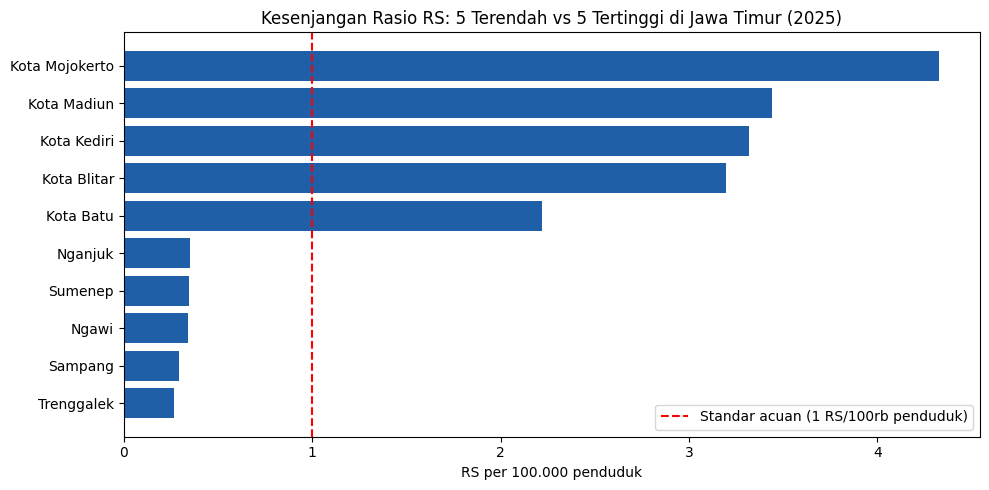

In [31]:
plot_df = pd.concat([
    j25.sort_values('rs_per_100rb').head(5),
    j25.sort_values('rs_per_100rb', ascending=False).head(5)
]).sort_values('rs_per_100rb')

plt.figure(figsize=(10,5))
plt.barh(plot_df['wilayah'], plot_df['rs_per_100rb'], color='#1f5fa8')
plt.axvline(1.0, color='red', linestyle='--', label='Standar acuan (1 RS/100rb penduduk)')
plt.xlabel('RS per 100.000 penduduk')
plt.title('Kesenjangan Rasio RS: 5 Terendah vs 5 Tertinggi di Jawa Timur (2025)')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
corr = nat_2025[["rs_per_100rb","kepadatan_per_km2","penduduk"]].corr()
print("Korelasi (nasional 2025)")
print(corr.round(3))

papua_lama = ["Papua", "Papua Barat", "Papua Barat Daya", "Papua Selatan", "Papua Tengah", "Papua Pegunungan"]
non_papua_2025 = nat_2025[~nat_2025.wilayah.isin(papua_lama)]
rest2020 = nat_2020[~nat_2020.wilayah.isin(["Papua","Papua Barat"])]

common = set(rest2020.wilayah) & set(non_papua_2025.wilayah)
trend = rest2020[rest2020.wilayah.isin(common)][["wilayah","total_rs","penduduk"]].merge(
    non_papua_2025[non_papua_2025.wilayah.isin(common)][["wilayah","total_rs","penduduk"]],
    on="wilayah", suffixes=("_2020","_2025"))
trend["growth_rs_pct"] = (trend.total_rs_2025/trend.total_rs_2020 - 1)*100
trend["growth_pop_pct"] = (trend.penduduk_2025/trend.penduduk_2020 - 1)*100
trend["gap"] = trend["growth_pop_pct"] - trend["growth_rs_pct"]

print("\nProvinsi dengan RISIKO MEMBURUK (penduduk tumbuh lebih cepat dari RS)")
print(trend.sort_values("gap", ascending=False)[["wilayah","growth_rs_pct","growth_pop_pct","gap"]].head(5).round(2).to_string(index=False))

Korelasi (nasional 2025)
                   rs_per_100rb  kepadatan_per_km2  penduduk
rs_per_100rb              1.000              0.129    -0.391
kepadatan_per_km2         0.129              1.000     0.154
penduduk                 -0.391              0.154     1.000

Provinsi dengan RISIKO MEMBURUK (penduduk tumbuh lebih cepat dari RS)
        wilayah  growth_rs_pct  growth_pop_pct   gap
         Maluku          -6.45            6.58 13.03
 Sumatera Utara          -5.45            6.67 12.12
  DI Yogyakarta          -3.61            3.07  6.69
Sulawesi Tengah           2.50            5.71  3.21
        Lampung           3.75            5.72  1.97


In [33]:
STANDAR = 1.0

j25 = j25.copy()
j25["rs_ideal"] = np.ceil(j25["penduduk"] / 100000 * STANDAR)
j25["defisit_rs"] = (j25["rs_ideal"] - j25["total_rs"]).clip(lower=0)
j25["skor_risiko"] = (STANDAR - j25["rs_per_100rb"]).clip(lower=0)
j25["skor_risiko_norm"] = j25["skor_risiko"] / j25["skor_risiko"].max()
j25 = j25.sort_values("defisit_rs", ascending=False)

print("TOP 10 wilayah dengan DEFISIT RS terbesar")
print(j25[["wilayah","penduduk","total_rs","rs_per_100rb","rs_ideal","defisit_rs"]].head(10).to_string(index=False))
print(f"\nTotal defisit RS se-Jatim: {int(j25['defisit_rs'].sum())} unit")

TOP 10 wilayah dengan DEFISIT RS terbesar
    wilayah  penduduk  total_rs  rs_per_100rb  rs_ideal  defisit_rs
     Jember   2620135      13.0      0.496158      27.0        14.0
     Kediri   1702262       9.0      0.528708      18.0         9.0
  Bangkalan   1112956       4.0      0.359403      12.0         8.0
    Nganjuk   1138604       4.0      0.351307      12.0         8.0
   Pasuruan   1669400       9.0      0.539116      17.0         8.0
    Sampang   1027538       3.0      0.291960      11.0         8.0
    Sumenep   1159397       4.0      0.345007      12.0         8.0
      Tuban   1231374       6.0      0.487261      13.0         7.0
Probolinggo   1193272       5.0      0.419016      12.0         7.0
      Ngawi    887172       3.0      0.338153       9.0         6.0

Total defisit RS se-Jatim: 143 unit


In [34]:
BUDGET_UNIT = 40

wilayah_list = j25["wilayah"].tolist()
defisit = dict(zip(j25.wilayah, j25.defisit_rs))
risiko = dict(zip(j25.wilayah, j25.skor_risiko_norm))
penduduk = dict(zip(j25.wilayah, j25.penduduk))

prob = pulp.LpProblem("Alokasi_RS_Baru_Jatim", pulp.LpMinimize)
x = {w: pulp.LpVariable(f"x_{i}", lowBound=0, upBound=defisit[w], cat="Integer")
     for i, w in enumerate(wilayah_list)}
prob += pulp.lpSum([(defisit[w] - x[w]) * risiko[w] for w in wilayah_list])
prob += pulp.lpSum([x[w] for w in wilayah_list]) <= BUDGET_UNIT
prob.solve(pulp.PULP_CBC_CMD(msg=0))

hasil = pd.DataFrame({
    "wilayah": wilayah_list,
    "defisit_awal": [defisit[w] for w in wilayah_list],
    "rs_baru_dialokasikan": [int(x[w].value()) for w in wilayah_list],
})
hasil["defisit_tersisa"] = hasil["defisit_awal"] - hasil["rs_baru_dialokasikan"]
hasil = hasil.sort_values("rs_baru_dialokasikan", ascending=False)

print("Status solver:", pulp.LpStatus[prob.status])
print(f"Total anggaran terpakai: {hasil['rs_baru_dialokasikan'].sum()} dari {BUDGET_UNIT} unit")
print(f"Nilai objektif: {pulp.value(prob.objective):.3f}")
print(f"Jumlah wilayah tersentuh: {(hasil.rs_baru_dialokasikan > 0).sum()}")
print()
print(hasil.head(15).to_string(index=False))

Status solver: Optimal
Total anggaran terpakai: 40 dari 40 unit
Nilai objektif: 60.703
Jumlah wilayah tersentuh: 6

    wilayah  defisit_awal  rs_baru_dialokasikan  defisit_tersisa
    Sampang           8.0                     8              0.0
    Nganjuk           8.0                     8              0.0
    Sumenep           8.0                     8              0.0
      Ngawi           6.0                     6              0.0
 Trenggalek           6.0                     6              0.0
  Bangkalan           8.0                     4              4.0
   Pasuruan           8.0                     0              8.0
     Kediri           9.0                     0              9.0
     Jember          14.0                     0             14.0
      Tuban           7.0                     0              7.0
Probolinggo           7.0                     0              7.0
 Banyuwangi           5.0                     0              5.0
  Bondowoso           5.0              

PERBANDINGAN SKENARIO
Skenario A (tanpa batas): 6 wilayah tersentuh | nilai objektif 60.70
Skenario B (cap 4/wilayah): 10 wilayah tersentuh | nilai objektif 62.53


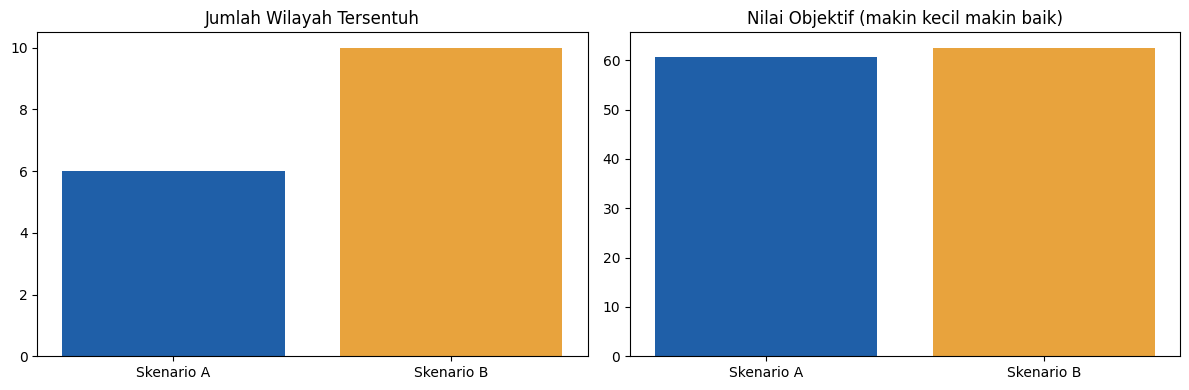

In [35]:
CAP_PER_WILAYAH = 4

prob_b = pulp.LpProblem("Alokasi_RS_Baru_Jatim_Pemerataan", pulp.LpMinimize)
xb = {w: pulp.LpVariable(f"xb_{i}", lowBound=0, upBound=min(defisit[w], CAP_PER_WILAYAH), cat="Integer")
      for i, w in enumerate(wilayah_list)}
prob_b += pulp.lpSum([(defisit[w] - xb[w]) * risiko[w] for w in wilayah_list])
prob_b += pulp.lpSum([xb[w] for w in wilayah_list]) <= BUDGET_UNIT
prob_b.solve(pulp.PULP_CBC_CMD(msg=0))

hasil_b = pd.DataFrame({
    "wilayah": wilayah_list,
    "defisit_awal": [defisit[w] for w in wilayah_list],
    "rs_baru_dialokasikan": [int(xb[w].value()) for w in wilayah_list],
})
hasil_b["defisit_tersisa"] = hasil_b["defisit_awal"] - hasil_b["rs_baru_dialokasikan"]

n_a = (hasil.rs_baru_dialokasikan > 0).sum()
n_b = (hasil_b.rs_baru_dialokasikan > 0).sum()

print("PERBANDINGAN SKENARIO")
print(f"Skenario A (tanpa batas): {n_a} wilayah tersentuh | nilai objektif {pulp.value(prob.objective):.2f}")
print(f"Skenario B (cap {CAP_PER_WILAYAH}/wilayah): {n_b} wilayah tersentuh | nilai objektif {pulp.value(prob_b.objective):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(["Skenario A","Skenario B"], [n_a, n_b], color=['#1f5fa8','#e8a33d'])
ax[0].set_title("Jumlah Wilayah Tersentuh")
ax[1].bar(["Skenario A","Skenario B"], [pulp.value(prob.objective), pulp.value(prob_b.objective)], color=['#1f5fa8','#e8a33d'])
ax[1].set_title("Nilai Objektif (makin kecil makin baik)")
plt.tight_layout()
plt.show()